In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,roc_curve,confusion_matrix,roc_auc_score

In [89]:
df = pd.read_csv('bank_churners_cleaned.csv')

In [47]:
df.head(2)

,Gender,Income_Category_ordered,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Relationship_Count,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag
0,0,3,1,3,5,777,1144,42,1.625,0.061,0
1,1,1,1,2,6,864,1291,33,3.714,0.105,0


In [48]:
df.columns

Index(['Gender', 'Income_Category_ordered', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Total_Relationship_Count',
       'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Attrition_Flag'],
      dtype='object')

In [49]:
print('total columns:',len(df.columns))

total columns: 11


In [50]:
df.isnull().sum()

Gender                      0
Income_Category_ordered     0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Total_Relationship_Count    0
Total_Revolving_Bal         0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
Attrition_Flag              0
dtype: int64

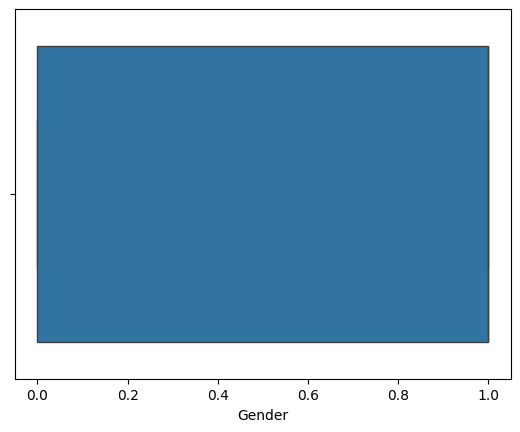

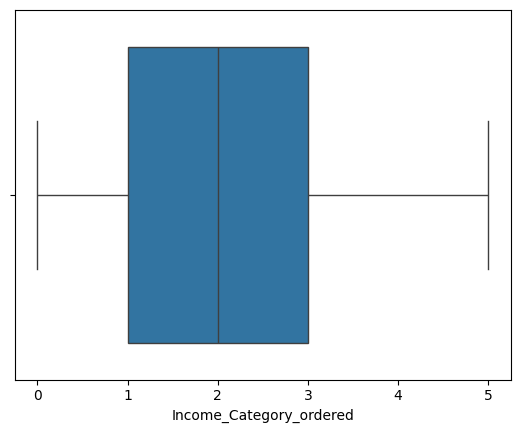

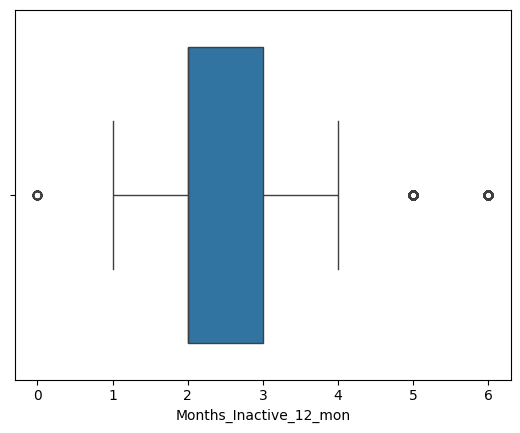

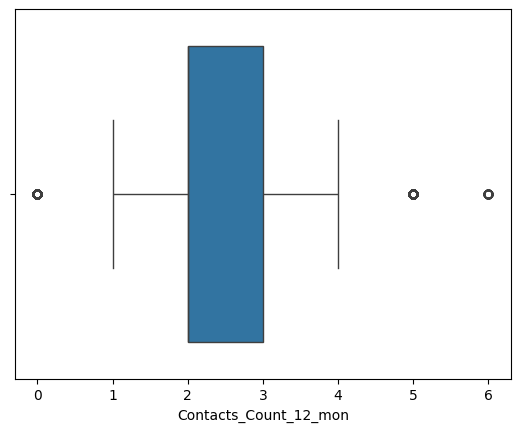

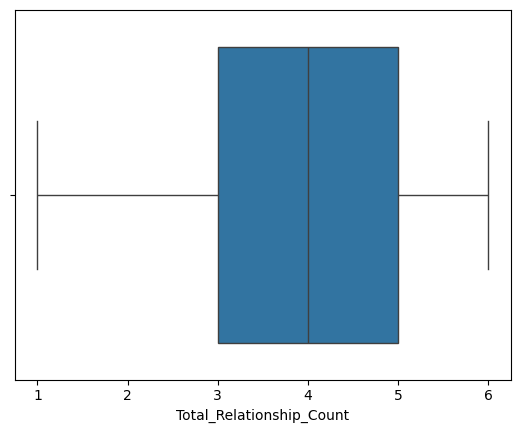

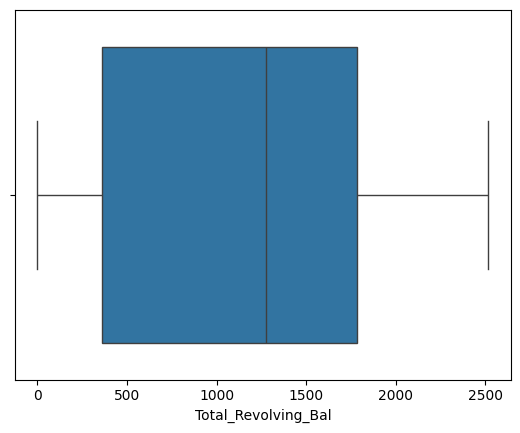

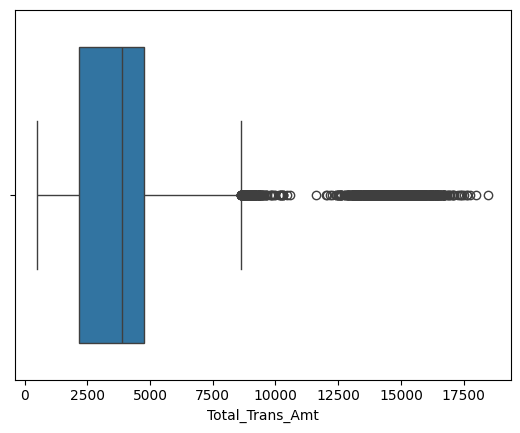

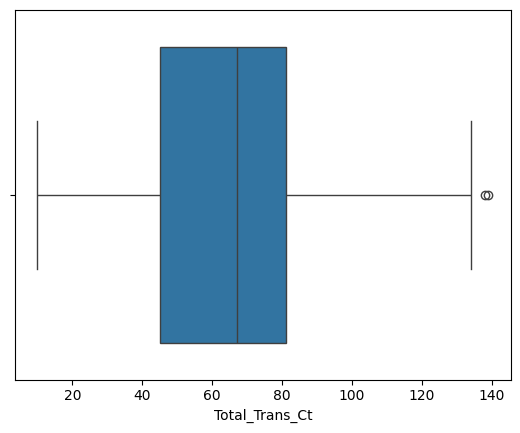

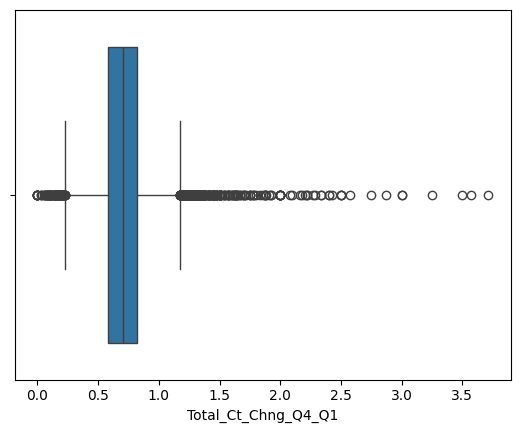

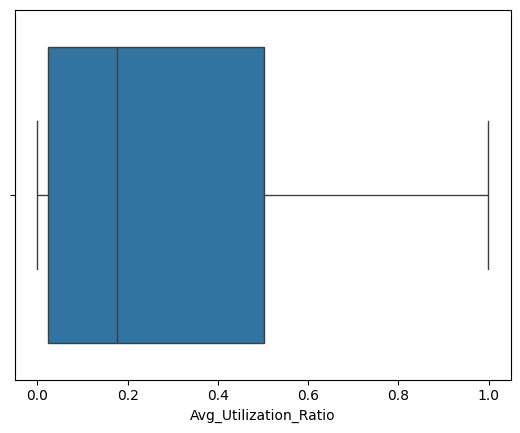

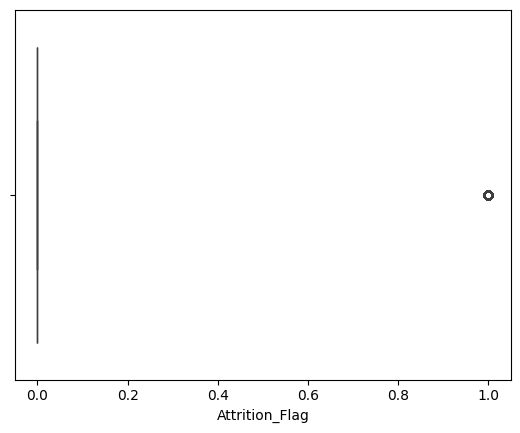

In [51]:
for i in df.columns:
    sns.boxplot(x=df[i])
    plt.show()

In [52]:
heavy_outliers = [
    'Total_Trans_Amt',
    'Total_Ct_Chng_Q4_Q1',
]
scaler=StandardScaler()
minMaxScaler = MinMaxScaler()
RBScaler = RobustScaler()

In [53]:
df.head()

,Gender,Income_Category_ordered,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Relationship_Count,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag
0,0,3,1,3,5,777,1144,42,1.625,0.061,0
1,1,1,1,2,6,864,1291,33,3.714,0.105,0
2,0,4,1,0,4,0,1887,20,2.333,0.000,0
3,1,1,4,1,3,2517,1171,20,2.333,0.760,0
4,0,3,1,0,5,0,816,28,2.500,0.000,0


In [61]:
important_features = list(df.columns)
important_features.pop(-1)
print(important_features)

['Gender', 'Income_Category_ordered', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Relationship_Count', 'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [69]:
X = df[important_features]
y = df['Attrition_Flag']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=43,stratify=y)
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.fit_transform(X_test)
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train,y_train)

C:\Users\NISHANT SHARMA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [77]:
y_pred = LR.predict(X_test)
probabs = LR.predict_proba(X_test)

In [72]:
probabs

array([[0.14110815, 0.85889185],
       [0.63202694, 0.36797306],
       [0.74753674, 0.25246326],
       ...,
       [0.99652136, 0.00347864],
       [0.98161055, 0.01838945],
       [0.87364605, 0.12635395]], shape=(3039, 2))

Logistic Regression Performance
Accuracy:0.9029285949325436
classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2551
           1       0.76      0.58      0.66       488

    accuracy                           0.90      3039
   macro avg       0.84      0.77      0.80      3039
weighted avg       0.90      0.90      0.90      3039



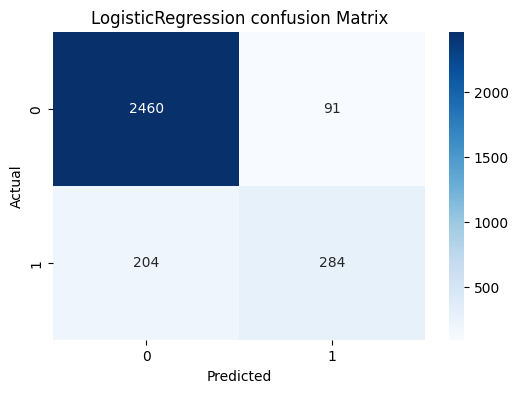

In [87]:
print('Logistic Regression Performance')
print(f'Accuracy:{accuracy_score(y_test,y_pred)}')
print('classification Report')
print(classification_report(y_test,y_pred))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True,fmt='d',cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('LogReg_confusion_matrix.png',dpi=300,bbox_inches='tight')
plt.title('LogisticRegression confusion Matrix')
plt.show()

In [99]:
probabs = LR.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test,probabs)
fpr,tpr,threshold = roc_curve(y_test,probabs)

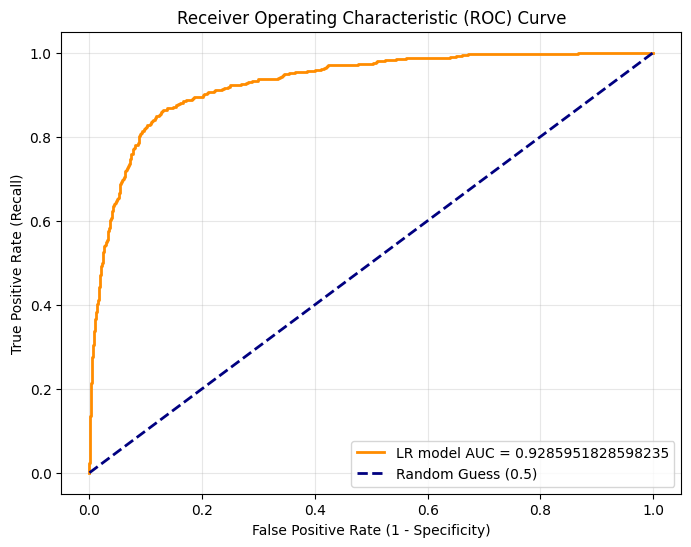

In [101]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'LR model AUC = {auc_score}')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--', label='Random Guess (0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.savefig('roc_curve_LR.png',dpi=300,bbox_inches='tight')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()